In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cv2

In [4]:
from sklearn.datasets import fetch_openml

In [5]:
mnist=fetch_openml('mnist_784')
x=mnist.data
y=mnist.target

In [6]:
mnist.data.shape

(70000, 784)

In [7]:
print(np.max(x))

255


In [8]:
x.shape

(70000, 784)

In [9]:
x.isna().sum()

pixel1      0
pixel2      0
pixel3      0
pixel4      0
pixel5      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 784, dtype: int64

**checking if dataset is loaded or not**

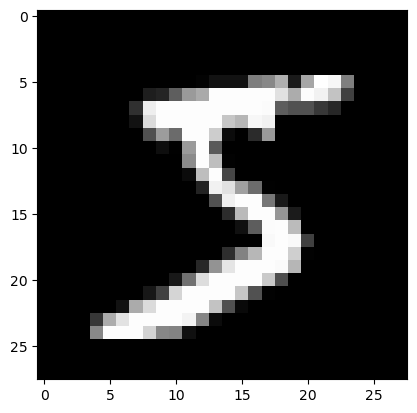

In [10]:
plt.imshow(x.iloc[0].values.reshape(28,28),cmap='gray')
plt.show()

**Normalize tha data**#pixels ranges fron 0_255 so we scale them b/w 0-1

In [11]:
x=x/255.0

In [12]:
x

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
print(np.min(x))
print(np.max(x))

0.0
1.0


In [14]:
x.describe()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,70000.0,...,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000774,0.000390,0.000183,0.000065,0.000051,0.000007,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.023495,0.016691,0.010917,0.006125,0.006093,0.001258,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.996078,0.996078,0.992157,0.992157,0.996078,0.243137,0.0,0.0,0.0,0.0


**reduce dimensions**

In [15]:
from sklearn.decomposition import PCA

In [16]:
pca=PCA(n_components=50)
x_reduced=pca.fit_transform(x)#this makes traing faster and cleaser

In [17]:
x_reduced.shape

(70000, 50)

**K mean clustering**

In [18]:
from sklearn.cluster import KMeans

In [52]:
kmeans=KMeans(n_clusters=10)
kmeans.fit_transform(x_reduced)
clusters=kmeans.labels_

**visulize cluster**

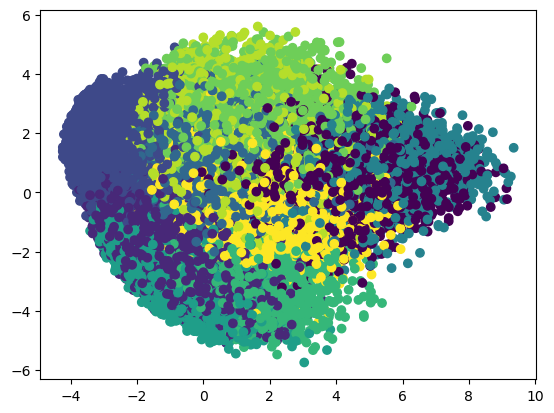

In [53]:
plt.scatter(x_reduced[:,0],x_reduced[:,1],c=clusters)
plt.show()

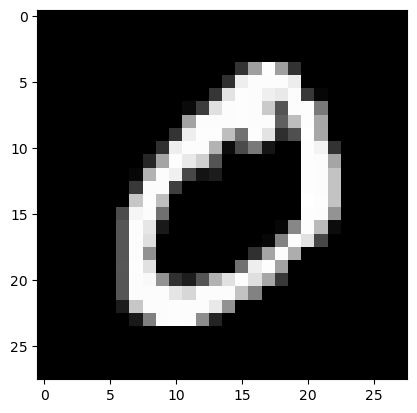

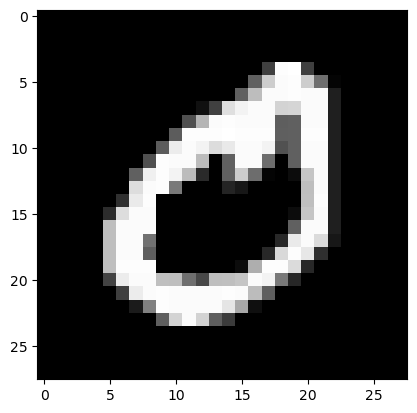

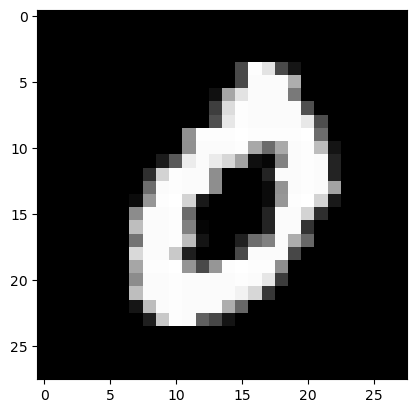

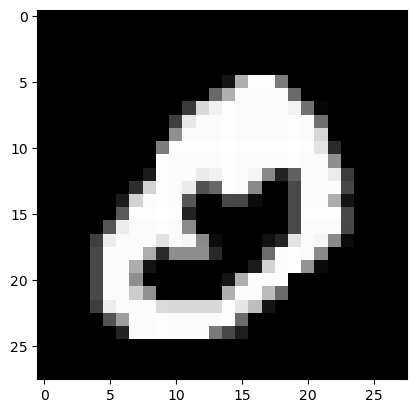

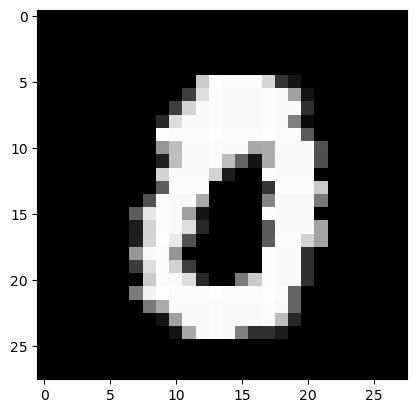

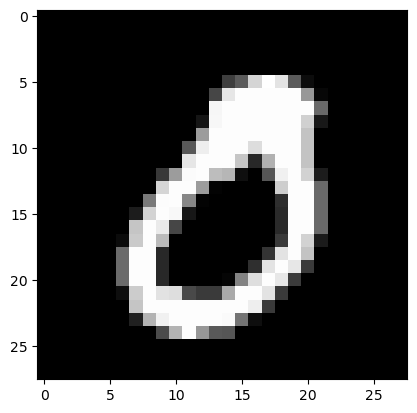

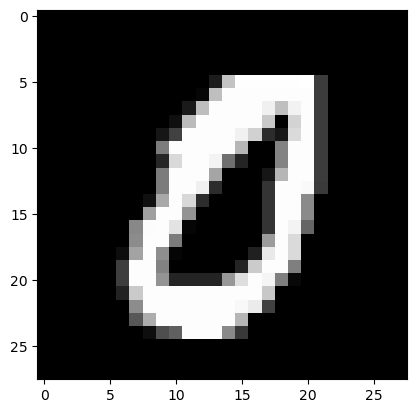

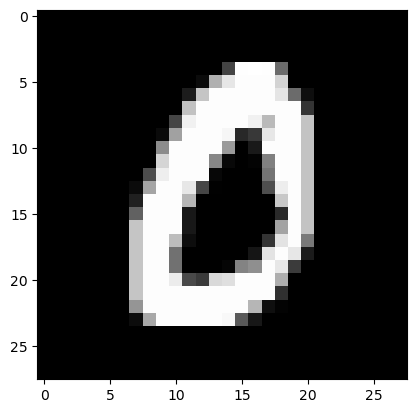

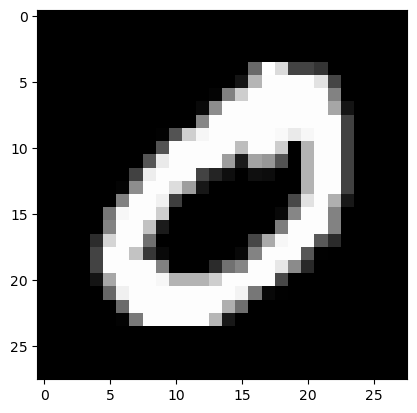

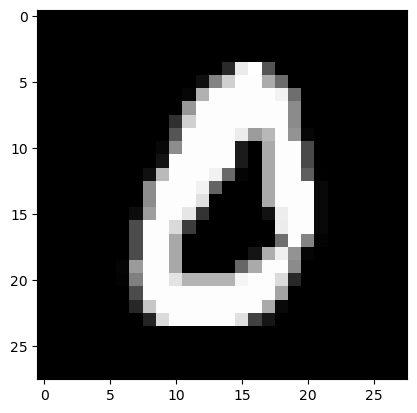

In [54]:
cluster_id=0;
indices=np.where(clusters==cluster_id)[0]
for i in indices[:10]:
    plt.imshow(x.iloc[i].values.reshape(28,28),cmap='gray')
    plt.show()

In [55]:
# cluster_id=1;
# indices=np.where(clusters==cluster_id)[0]
# for i in indices[:10]:
#     plt.imshow(x.iloc[i].values.reshape(28,28),cmap='gray')
#     plt.show()

In [56]:
# cluster_id=5;
# indices=np.where(clusters==cluster_id)[0]
# for i in indices[:10]:
#     plt.imshow(x.iloc[i].values.reshape(28,28),cmap='gray')
#     plt.show()

In [57]:
# cluster_id=1;
# indices=np.where(clusters==cluster_id)[0]
# for i in indices[:10]:
#     plt.imshow(x.iloc[i].values.reshape(28,28),cmap='gray')
#     plt.show()

**Evaluating cluster**

In [58]:
from sklearn.metrics import silhouette_score

In [ ]:
score=silhouette_score(x_reduced,clusters)
print("silhouette score :",score)